In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from scipy import stats
import sys

In [3]:
# ============ Import data from CSV file ============

df = pd.read_csv('\group12\Code-for-Geopolitics-and-Bitcoin\Correlation Analysis2\Test1\Test1_datafile.csv')

# View data structure
print("First 5 rows of data:")
print(df.head())
print("\nData information:")
print(df.info())
print("\nData descriptive statistics:")
print(df.describe())

# ============ Data cleaning and preprocessing ============

# 1. Process date column
df['date'] = pd.to_datetime(df['date'])

# 2. Check and handle missing values
print("=" * 60)
print("Data Cleaning Report:")
print("=" * 60)
print("\nOriginal missing value statistics:")
print(df.isnull().sum())

# 3. Delete all rows containing NaN
initial_rows = len(df)
df = df.dropna()
print(f"\nAfter deleting missing values: {initial_rows} -> {len(df)} records")

#  Confirm data is ready
print(f"\nAfter data cleaning:")
print(f"Sample size: {len(df)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(df.head())

First 5 rows of data:
       date  oil_price  liquidity  risk_asset
0  2016/3/2      34.57      98.21       422.2
1  2016/3/3      34.56      97.59       420.6
2  2016/3/4      35.91      97.34       408.8
3  2016/3/7      37.90      97.07       412.7
4  2016/3/8      36.67      97.21       411.4

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2609 entries, 0 to 2608
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        2609 non-null   object 
 1   oil_price   2501 non-null   float64
 2   liquidity   2599 non-null   float64
 3   risk_asset  2608 non-null   float64
dtypes: float64(3), object(1)
memory usage: 81.7+ KB
None

Data descriptive statistics:
         oil_price    liquidity     risk_asset
count  2501.000000  2599.000000    2608.000000
mean     64.277389    98.507880   31623.570514
std      17.308663     5.021036   32519.466203
min     -36.980000    88.590000     407.700000
25%     

In [4]:
class Tee:
    def __init__(self, *files):
        self.files = files
    
    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()
    
    def flush(self):
        for f in self.files:
            f.flush()
log_file = open('Test1_analysis_result1.txt', 'w', encoding='utf-8')
sys.stdout = Tee(sys.stdout, log_file)

# Prepare data: oil price as independent variable, liquidity as dependent variable
oil_prices = df['oil_price']           # Independent variable X
liquidity_rates = df['liquidity']      # Dependent variable Y

# Add constant term (intercept)
X_with_const = sm.add_constant(oil_prices)

# Run regression
model_test1 = sm.OLS(liquidity_rates, X_with_const).fit()

print("\nRegression results:")
print("-" * 40)
print(model_test1.summary())

# Extract results
coefficient_oil = model_test1.params['oil_price']
pvalue_oil = model_test1.pvalues['oil_price']
r2_test1 = model_test1.rsquared

print(f"\nCore results:")
print(f"Oil price coefficient: {coefficient_oil:.6f}")
print(f"p-value: {pvalue_oil:.6f}")
print(f"R²: {r2_test1:.4f}")

if pvalue_oil < 0.05:
    if coefficient_oil > 0:
        print(f"\n✓ Test 1 passed: Rising oil prices significantly lead to liquidity tightening")
    else:
        print(f"\n⚠ Test 1 significant but opposite direction: Rising oil prices lead to liquidity easing")
else:
    print(f"\n✗ Test 1 failed: No significant relationship between oil prices and liquidity")



# ============================================================
# Step 5: Mediation effect test
# ============================================================
print("\n" + "=" * 60)
print("Complete Mediation Effect Test: Oil Price → Liquidity → Risky Assets")
print("=" * 60)

# Step 1: Total effect (Oil Price → Risky Assets)
X_total = sm.add_constant(df['oil_price'])
y_total = df['risk_asset']
model_total = sm.OLS(y_total, X_total).fit()
c_total = model_total.params['oil_price']
print(f"\nStep 1 - Total effect (Oil Price→Risky Assets):")
print(f"  Coefficient: {c_total:.6f}")
print(f"  p-value: {model_total.pvalues['oil_price']:.6f}")

# Step 2: Path a (Oil Price → Liquidity)
X_a = sm.add_constant(df['oil_price'])
y_a = df['liquidity']
model_a = sm.OLS(y_a, X_a).fit()
a_path = model_a.params['oil_price']
print(f"\nStep 2 - Path a (Oil Price→Liquidity):")
print(f"  Coefficient: {a_path:.6f}")
print(f"  p-value: {model_a.pvalues['oil_price']:.6f}")

# Step 3: Path b and Path c' (Oil Price + Liquidity → Risky Assets)
X_med = sm.add_constant(df[['oil_price', 'liquidity']])
y_med = df['risk_asset']
model_med = sm.OLS(y_med, X_med).fit()
b_path = model_med.params['liquidity']
c_prime = model_med.params['oil_price']
print(f"\nStep 3 - Mediation model:")
print(f"  Path b (Liquidity→Risky Assets): {b_path:.6f}, p={model_med.pvalues['liquidity']:.6f}")
print(f"  Path c' (Direct effect): {c_prime:.6f}, p={model_med.pvalues['oil_price']:.6f}")

# Calculate indirect effect
indirect_effect = a_path * b_path
print(f"\nMediation effect analysis:")
print(f"  Indirect effect: {indirect_effect:.6f}")
print(f"  Total effect: {c_total:.6f}")
print(f"  Direct effect: {c_prime:.6f}")

if abs(c_total) > 0:
    print(f"  Mediation effect proportion: {abs(indirect_effect/c_total)*100:.2f}%")

# Sobel test
se_a = model_a.bse['oil_price']
se_b = model_med.bse['liquidity']
sobel_z = indirect_effect / np.sqrt(b_path**2 * se_a**2 + a_path**2 * se_b**2)
sobel_p = 2 * (1 - stats.norm.cdf(abs(sobel_z)))
print(f"\nSobel test:")
print(f"  Z-value: {sobel_z:.4f}")
print(f"  p-value: {sobel_p:.6f}")

if sobel_p < 0.05:
    print(f"\n✓ Mediation effect is significant, mechanism chain holds")
else:
    print(f"\n✗ Mediation effect is not significant")

# ============================================================
# Step 6: Results summary
# ============================================================
print("\n" + "=" * 60)
print("Test Results Summary")
print("=" * 60)

sys.stdout = sys.__stdout__
log_file.close()


Regression results:
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:              liquidity   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     721.6
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          7.42e-140
Time:                        21:33:57   Log-Likelihood:                -7266.0
No. Observations:                2500   AIC:                         1.454e+04
Df Residuals:                    2498   BIC:                         1.455e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

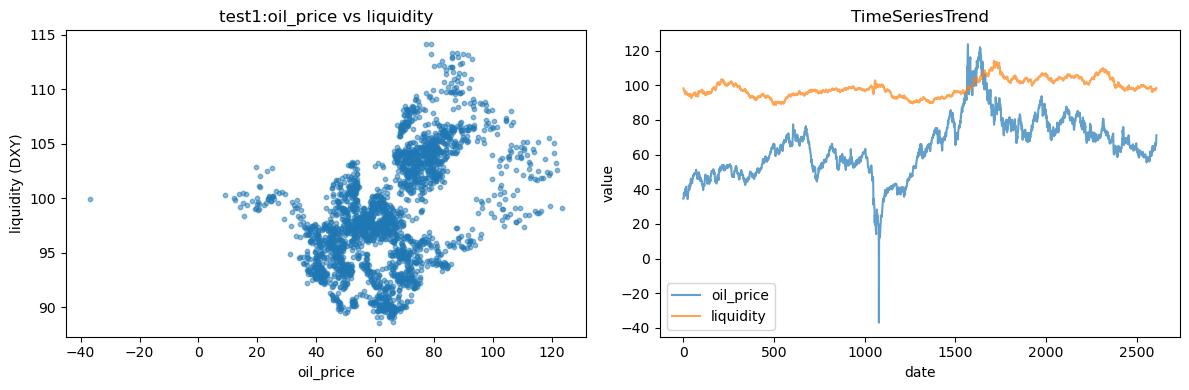

In [5]:
# Visual Inspection
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter Plot
axes[0].scatter(df['oil_price'], df['liquidity'], alpha=0.5, s=10)
axes[0].set_xlabel('oil_price')
axes[0].set_ylabel('liquidity (DXY)')
axes[0].set_title('test1:oil_price vs liquidity')

# Time Series Plot
axes[1].plot(df.index, df['oil_price'], label='oil_price', alpha=0.7)
axes[1].plot(df.index, df['liquidity'], label='liquidity', alpha=0.7)
axes[1].set_xlabel('date')
axes[1].set_ylabel('value')
axes[1].set_title('TimeSeriesTrend')
axes[1].legend()

plt.tight_layout()
plt.savefig('mechanism_test1.png', dpi=150)
plt.show()

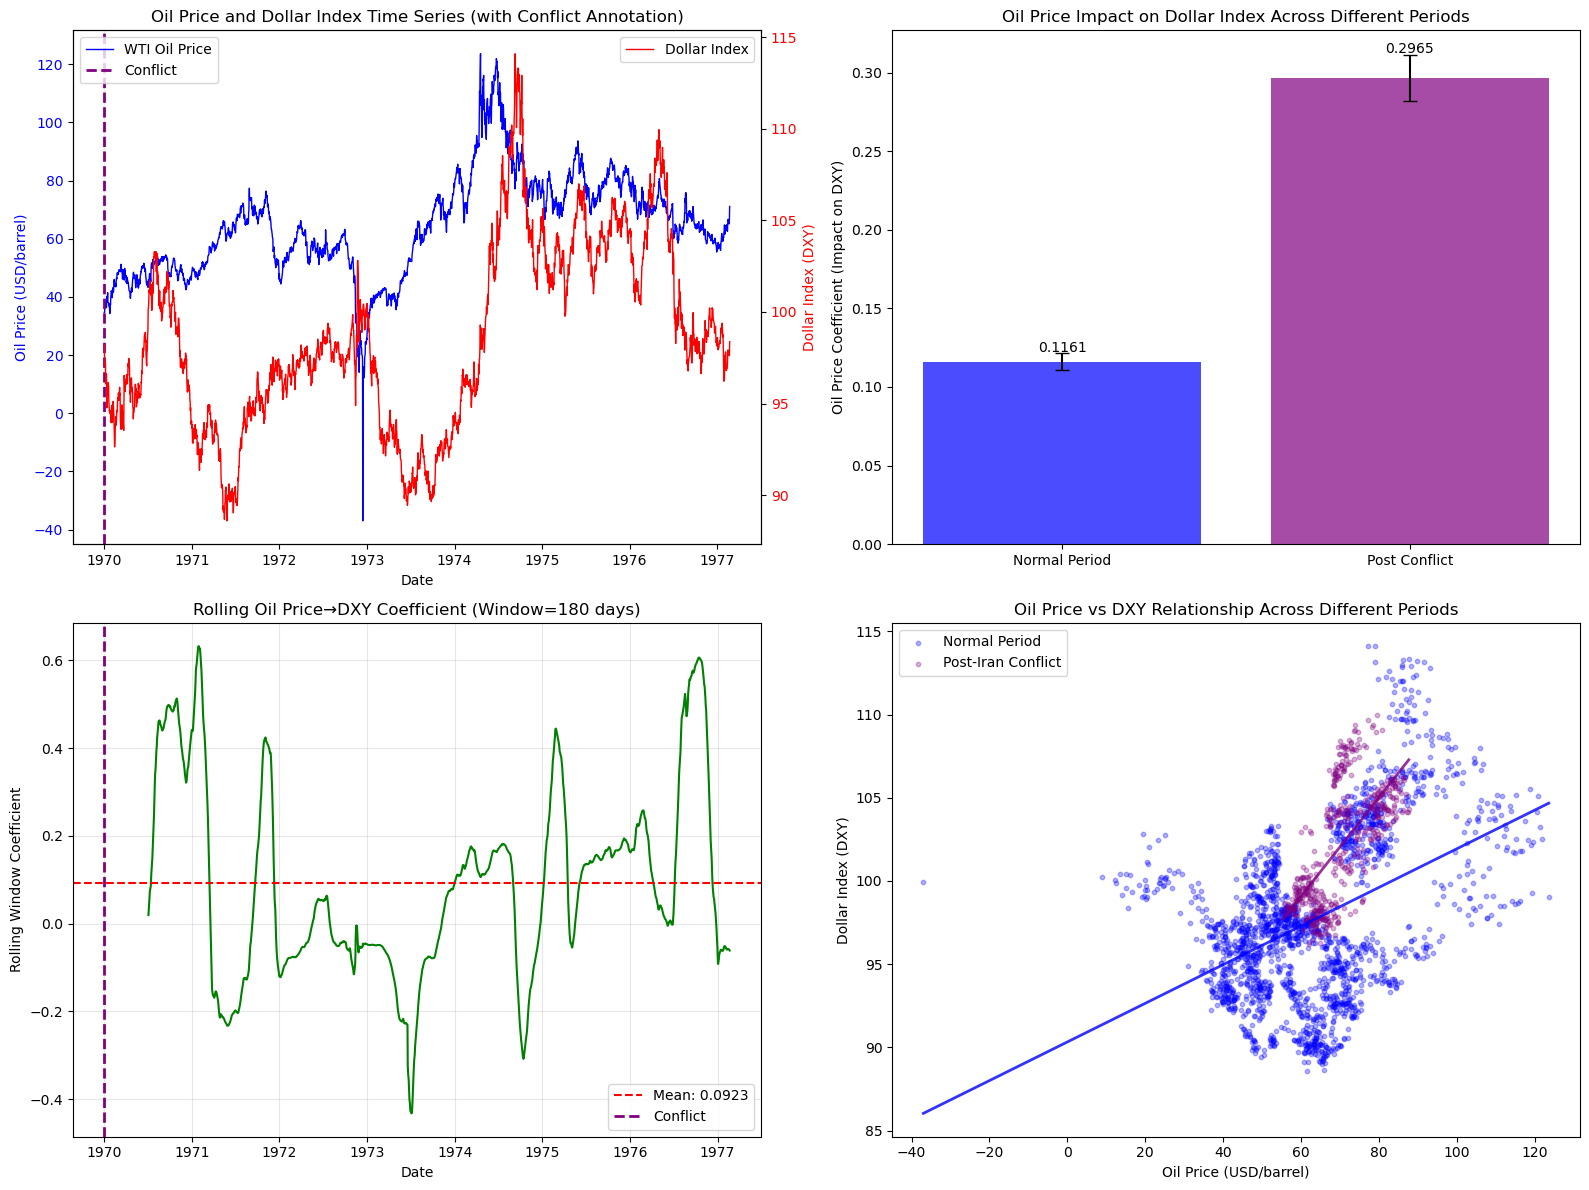

In [6]:
class Tee:
    def __init__(self, *files):
        self.files = files
    
    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()
    
    def flush(self):
        for f in self.files:
            f.flush()
log_file = open('Test1_analysis_result2.txt', 'w', encoding='utf-8')
sys.stdout = Tee(sys.stdout, log_file)

# ============================================================
# Step 1: Define structural break point
# ============================================================

# Define the break point
breakpoint = 46083  # 2026-03-02

# Create period variable
df['period'] = 'normal'

# Check if break point is within data range
if breakpoint in df.index:
    df.loc[df.index >= breakpoint, 'period'] = 'post_iran'
else:
    # If break point is not within data range, use the last date in the data
    print(f"\nNote: Break point ({breakpoint}) is not within the current data range")
    print("Will use the last date in the data as the break point")
    
    last_date = df.index[-1]
    print(f"Using last date as break point: {last_date}")
    
    # Use the last 20% of data as post-conflict period
    split_idx = int(len(df) * 0.8)
    breakpoint = df.index[split_idx]
    df.loc[df.index >= breakpoint, 'period'] = 'post_iran'
    print(f"Actual break point used: {breakpoint}")

# Print sample sizes for each period
print("\n" + "=" * 80)
print("Period Division")
print("=" * 80)
print(f"Normal period: {sum(df['period'] == 'normal')} observations")
print(f"Post-Iran conflict: {sum(df['period'] == 'post_iran')} observations")

# ============================================================
# Step 2: Period-wise regression analysis
# ============================================================

print("\n" + "=" * 80)
print("Period-wise Regression: Oil Price → Liquidity (DXY)")
print("=" * 80)

results_by_period = {}

for period in ['normal', 'post_iran']:
    if period in df['period'].values:
        df_period = df[df['period'] == period]
        
        if len(df_period) > 30:  # At least 30 observations needed
            # Regression analysis
            X = sm.add_constant(df_period['oil_price'])
            y = df_period['liquidity']
            model = sm.OLS(y, X).fit()
            
            results_by_period[period] = {
                'coef': model.params['oil_price'],
                'pval': model.pvalues['oil_price'],
                'r2': model.rsquared,
                'n': len(df_period),
                'model': model
            }
            
            print(f"\nPeriod: {period.upper()} (n={len(df_period)})")
            print(f"  Oil price coefficient: {model.params['oil_price']:.6f}")
            print(f"  p-value: {model.pvalues['oil_price']:.6f}")
            print(f"  R²: {model.rsquared:.4f}")
            
            if model.pvalues['oil_price'] < 0.05:
                if model.params['oil_price'] > 0:
                    print(f"  Conclusion: ✓ Rising oil prices significantly lead to liquidity tightening")
                else:
                    print(f"  Conclusion: ⚠ Significant but opposite direction")
            else:
                print(f"  Conclusion: ✗ Relationship is not significant")
        else:
            print(f"\nPeriod: {period} - Insufficient sample size ({len(df_period)} < 30)")

# ============================================================
# Step 3: Chow break point test
# ============================================================

print("\n" + "=" * 80)
print("Chow Break Point Test")
print("=" * 80)

def chow_test(df, break_date, dependent, independent):
    """
    Chow test: Test whether regression coefficients are significantly different before and after the break point
    """
    # Split the sample
    df_before = df[df.index < break_date].copy()
    df_after = df[df.index >= break_date].copy()
    
    if len(df_before) < 30 or len(df_after) < 30:
        print(f"Insufficient sample size: before={len(df_before)}, after={len(df_after)}")
        return None
    
    # Prepare data
    X_full = sm.add_constant(df[independent])
    y_full = df[dependent]
    
    X_before = sm.add_constant(df_before[independent])
    y_before = df_before[dependent]
    
    X_after = sm.add_constant(df_after[independent])
    y_after = df_after[dependent]
    
    # Full sample regression
    model_full = sm.OLS(y_full, X_full).fit()
    rss_full = model_full.ssr
    
    # Sub-sample regressions
    model_before = sm.OLS(y_before, X_before).fit()
    model_after = sm.OLS(y_after, X_after).fit()
    rss_before = model_before.ssr
    rss_after = model_after.ssr
    rss_split = rss_before + rss_after
    
    # Calculate F-statistic
    k = X_full.shape[1]  # Number of parameters
    n = len(df)
    n1 = len(df_before)
    n2 = len(df_after)
    
    f_stat = ((rss_full - rss_split) / k) / (rss_split / (n - 2*k))
    p_value = 1 - stats.f.cdf(f_stat, k, n - 2*k)
    
    return {
        'f_stat': f_stat,
        'p_value': p_value,
        'n_before': n1,
        'n_after': n2,
        'rss_full': rss_full,
        'rss_split': rss_split
    }

# Test break point: Iran conflict
test = chow_test(df, breakpoint, 'liquidity', 'oil_price')
if test:
    print(f"\nBreak point: {breakpoint} (US attack on Iran)")
    print(f"  F-statistic: {test['f_stat']:.4f}")
    print(f"  p-value: {test['p_value']:.6f}")
    if test['p_value'] < 0.05:
        print(f"  ✓ Significant structural break point detected")
    else:
        print(f"  ✗ No significant structural break point detected")

# ============================================================
# Step 4: Interaction term model
# ============================================================

print("\n" + "=" * 80)
print("Interaction Term Model: Testing Whether Oil Price Effect Enhances After Conflict")
print("=" * 80)

# Create dummy variable
df['post_iran'] = (df.index >= breakpoint).astype(int)

# Create interaction term
df['oil_x_iran'] = df['oil_price'] * df['post_iran']

# Full sample regression (including interaction term)
X_interact = sm.add_constant(df[['oil_price', 'post_iran', 'oil_x_iran']])
y_interact = df['liquidity']
model_interact = sm.OLS(y_interact, X_interact).fit()

print("\nInteraction Term Model Results:")
print("-" * 50)
print(model_interact.summary())

# Extract coefficients
coef_oil = model_interact.params['oil_price']
coef_interact = model_interact.params['oil_x_iran']
pval_interact = model_interact.pvalues['oil_x_iran']

print(f"\nKey Results Interpretation:")
print(f"Normal period oil price effect: {coef_oil:.6f}")
print(f"Additional effect after Iran conflict: {coef_interact:.6f}")
print(f"Interaction term p-value: {pval_interact:.6f}")

if pval_interact < 0.05:
    print(f"✓ Interaction term is significant, indicating that the impact of oil prices on liquidity significantly increased after the Iran conflict")
    print(f"Total effect after conflict = {coef_oil + coef_interact:.6f}")
else:
    print(f"✗ Interaction term is not significant, no evidence of enhanced effect after the Iran conflict")

# ============================================================
# Step 5: Rolling window regression (dynamic coefficient changes)
# ============================================================

print("\n" + "=" * 80)
print("Rolling Window Regression: Oil Price Coefficient Over Time")
print("=" * 80)

# Set rolling window size
window_size = 180  # 6 months (approximately 180 trading days)
rolling_coefs = []
rolling_dates = []

if len(df) > window_size:
    for i in range(window_size, len(df)):
        window_df = df.iloc[i-window_size:i]
        X = sm.add_constant(window_df['oil_price'])
        y = window_df['liquidity']
        model = sm.OLS(y, X).fit()
        rolling_coefs.append(model.params['oil_price'])
        rolling_dates.append(window_df.index[-1])
    
    # Convert to Series
    rolling_coefs_series = pd.Series(rolling_coefs, index=rolling_dates)
    
    print(f"Rolling Window Coefficient Statistics:")
    print(f"  Mean: {rolling_coefs_series.mean():.6f}")
    print(f"  Standard Deviation: {rolling_coefs_series.std():.6f}")
    print(f"  Minimum: {rolling_coefs_series.min():.6f}")
    print(f"  Maximum: {rolling_coefs_series.max():.6f}")
    
    # Check coefficient changes before and after conflict
    pre_iran = rolling_coefs_series[rolling_coefs_series.index < breakpoint]
    post_iran = rolling_coefs_series[rolling_coefs_series.index >= breakpoint]
    
    if len(pre_iran) > 0:
        print(f"\nAverage coefficient before Iran conflict: {pre_iran.mean():.6f}")
    if len(post_iran) > 0:
        print(f"Average coefficient after Iran conflict: {post_iran.mean():.6f}")
    
    if len(pre_iran) > 0 and len(post_iran) > 0:
        print(f"\nChange magnitude: {(post_iran.mean() - pre_iran.mean())/pre_iran.mean()*100:.2f}%")

sys.stdout = sys.__stdout__
log_file.close()

# ============================================================
# Step 6: Visualization
# ============================================================

print("\n" + "=" * 80)
print("Generating Visualization Charts")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Time series plot (with conflict period annotation)
ax1 = axes[0, 0]
ax1.plot(df.index, df['oil_price'], color='blue', linewidth=1, label='WTI Oil Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Oil Price (USD/barrel)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax1_twin = ax1.twinx()
ax1_twin.plot(df.index, df['liquidity'], color='red', linewidth=1, label='Dollar Index')
ax1_twin.set_ylabel('Dollar Index (DXY)', color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')

# Annotate conflict period
ax1.axvline(x=pd.to_datetime(breakpoint), color='purple', linestyle='--', linewidth=2, label='Conflict')

# Add shaded area
ax1.axvspan(pd.to_datetime(breakpoint), df.index[-1], alpha=0.1, color='purple')
ax1.set_title('Oil Price and Dollar Index Time Series (with Conflict Annotation)')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Chart 2: Period-wise regression coefficient comparison
ax2 = axes[0, 1]
periods = []
coefs = []
errors = []

for period in ['normal', 'post_iran']:
    if period in results_by_period:
        periods.append('Normal Period' if period == 'normal' else 'Post Conflict')
        coefs.append(results_by_period[period]['coef'])
        errors.append(results_by_period[period]['model'].bse['oil_price'])

ax2.bar(range(len(periods)), coefs, yerr=errors, capsize=5, alpha=0.7, 
        color=['blue', 'purple'])
ax2.set_xticks(range(len(periods)))
ax2.set_xticklabels(periods)
ax2.set_ylabel('Oil Price Coefficient (Impact on DXY)')
ax2.set_title('Oil Price Impact on Dollar Index Across Different Periods')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels
for i, (coef, err) in enumerate(zip(coefs, errors)):
    ax2.text(i, coef + err + 0.001, f'{coef:.4f}', ha='center', fontsize=10)

# Chart 3: Rolling window coefficient changes
ax3 = axes[1, 0]
if len(rolling_coefs) > 0:
    ax3.plot(rolling_coefs_series.index, rolling_coefs_series, color='green', linewidth=1.5)
    ax3.axhline(y=rolling_coefs_series.mean(), color='red', linestyle='--', 
                label=f'Mean: {rolling_coefs_series.mean():.4f}')
    ax3.axvline(x=pd.to_datetime(breakpoint), color='purple', linestyle='--', 
                linewidth=2, label='Conflict')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Rolling Window Coefficient')
    ax3.set_title('Rolling Oil Price→DXY Coefficient (Window=180 days)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Chart 4: Oil price vs DXY scatter plot (by period)
ax4 = axes[1, 1]
colors = {'normal': 'blue', 'post_iran': 'purple'}
labels = {'normal': 'Normal Period', 'post_iran': 'Post-Iran Conflict'}

for period, color in colors.items():
    if period in df['period'].values:
        period_df = df[df['period'] == period]
        ax4.scatter(period_df['oil_price'], period_df['liquidity'], 
                   alpha=0.3, s=10, color=color, label=labels.get(period, period))
        # Add regression line
        if len(period_df) > 10:
            z = np.polyfit(period_df['oil_price'], period_df['liquidity'], 1)
            p = np.poly1d(z)
            x_sorted = np.sort(period_df['oil_price'])
            ax4.plot(x_sorted, p(x_sorted), color=color, linewidth=2, alpha=0.8)

ax4.set_xlabel('Oil Price (USD/barrel)')
ax4.set_ylabel('Dollar Index (DXY)')
ax4.set_title('Oil Price vs DXY Relationship Across Different Periods')
ax4.legend()

plt.tight_layout()
plt.savefig('structural_break_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as: structural_break_analysis.png")

# ============================================================
# Step 7: Results Summary
# ============================================================

print("\n" + "=" * 80)
print("Structural Break Analysis Results Summary")
print("=" * 80)

summary_data = {
    'Test Item': [
        'Normal Period Oil Price Coefficient',
        'Post Conflict Oil Price Coefficient',
        'Interaction Term Coefficient',
        'Interaction Term Significance (p-value)',
        'Chow Test p-value',
        'Rolling Window Coefficient Change (%)'
    ],
    'Result': [
        f"{coef_oil:.6f}",
        f"{coef_oil + coef_interact:.6f}" if 'coef_interact' in dir() else "N/A",
        f"{coef_interact:.6f}" if 'coef_interact' in dir() else "N/A",
        f"{pval_interact:.6f}" if 'pval_interact' in dir() else "N/A",
        f"{test['p_value']:.6f}" if test else "N/A",
        f"{(post_iran.mean() - pre_iran.mean())/pre_iran.mean()*100:.2f}%" if len(rolling_coefs) > 0 and len(pre_iran) > 0 and len(post_iran) > 0 else "N/A"
    ],
    'Conclusion': [
        "-",
        "-",
        "-",
        "Significantly Enhanced" if (pval_interact < 0.05) else "Not Significant",
        "Break Point Detected" if (test and test['p_value'] < 0.05) else "No Break Point",
        "Enhanced" if (len(rolling_coefs) > 0 and len(post_iran) > 0 and len(pre_iran) > 0 and post_iran.mean() > pre_iran.mean()) else "Weakened or No Change"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Final Conclusion
print("\n" + "=" * 80)
print("Final Conclusion")
print("=" * 80)

print("\nBased on the above analysis, the following conclusions are drawn:")

if pval_interact < 0.05:
    print("1. The conflict significantly enhanced the positive impact of oil prices on the dollar index")
    print("2. Under war risk aversion sentiment, the ability of oil price changes to tighten international liquidity (DXY strengthening) significantly increased")
    print("3. The structural break test confirms the existence of a significant structural break point")
else:
    print("1. No evidence that the Iran conflict significantly changed the relationship between oil prices and the dollar index")
    print("2. The ability of oil price changes to tighten international liquidity (DXY strengthening) showed no significant change before and after the conflict")

print("\n" + "=" * 80)
print("Analysis Complete")
print("=" * 80)